In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [3]:
import numpy as np
import pandas as pd # get_dummies
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.datasets import mnist # mnist 데이터 셋 => 훈련셋과 테스트셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.layers import Dense, Input, Dropout
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler # 이미지 파일은 0 ~ 255의 값을 갖으므로 scaler 대신 값/255 사용
from sklearn.model_selection import train_test_split # 데이터 분리

In [5]:
# 1. 데이터 셋
width = 28 ; height = 28
(X_train, y_train),(X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

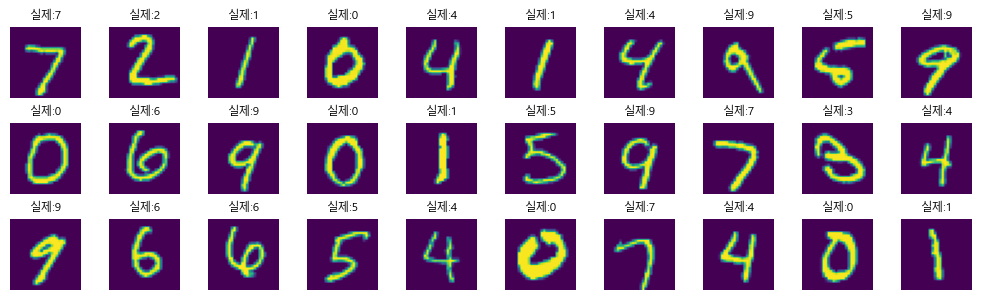

In [23]:
plt_row = 3
plt_col = 10
# plt.figure(figsize=(plt_col,plt_row))
plt.rcParams['figure.figsize'] = [plt_col, plt_row]
plt.rc('font', family = 'Malgun Gothic', size = 7) # 한글시각화용
# plt.rc('font', family = 'NanumBarumGothic') # 코랩 한글 시각화
fig, axes = plt.subplots(plt_row, plt_col)
# axes[0,0].imshow(X_test[0].reshape(width, height))
# axes[0,0].axis('off')
# title = '실제:{}'.format(y_test[0])
# axes[0,0].set_title(title)
# plt.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(plt_col*plt_row) :
    x = i//plt_col ; y = i%plt_col
    axes[x,y].imshow(X_test[i].reshape(width, height))
    axes[x,y].axis('off')
    title = '실제:{}'.format(y_test[i])
    axes[x,y].set_title(title)
plt.tight_layout()

# 1. DNN

In [31]:
%%time
# 1. 데이터 생성 및 전처리
width,height = 28,28
(X_train, y_train), (X_test,y_test) = mnist.load_data()
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 독립변수 28,28 => 784 1차원 -> 실수형으로 변환 -> 스케일 조정
X_train = X_train.reshape(-1,width*height).astype(np.float32)/255.0
X_val = X_val.reshape(-1,width*height).astype(np.float32)/255.0
X_test = X_test.reshape(-1,width*height).astype(np.float32)/255.0
# 타겟변수 원핫인코딩
Y_train = to_categorical(y_train)
Y_val = to_categorical(y_val)
Y_test = to_categorical(y_test)

X_train.shape, Y_train.shape, X_val.shape, Y_val.shape,X_test.shape, Y_test.shape

# 2. 모델 구성
model = Sequential([
    Input(width*height),
    Dense(1024, activation='relu'),
    Dropout(0.3),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax'),
])
# model.summary()
# 3. 학습설정
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics=['accuracy'])
model.fit(X_train, Y_train, epochs=50, validation_data=(X_val,Y_val))
# 노트북 환경에서 실행시키면 1h 45min이 걸려서 colab으로 학습하는게...

Epoch 1/50
1563/1563 [==============================] - 20s 13ms/step - loss: 0.2710 - accuracy: 0.9172 - val_loss: 0.1182 - val_accuracy: 0.9662
Epoch 2/50
1563/1563 [==============================] - 19s 12ms/step - loss: 0.1406 - accuracy: 0.9583 - val_loss: 0.1084 - val_accuracy: 0.9687
Epoch 3/50
1563/1563 [==============================] - 19s 12ms/step - loss: 0.1112 - accuracy: 0.9674 - val_loss: 0.0936 - val_accuracy: 0.9739
Epoch 4/50
1563/1563 [==============================] - 19s 12ms/step - loss: 0.0960 - accuracy: 0.9716 - val_loss: 0.0884 - val_accuracy: 0.9751
Epoch 5/50
1563/1563 [==============================] - 20s 13ms/step - loss: 0.0825 - accuracy: 0.9754 - val_loss: 0.1175 - val_accuracy: 0.9686
Epoch 6/50
1563/1563 [==============================] - 20s 13ms/step - loss: 0.0755 - accuracy: 0.9784 - val_loss: 0.0907 - val_accuracy: 0.9753
Epoch 7/50
1563/1563 [==============================] - 20s 13ms/step - loss: 0.0689 - accuracy: 0.9799 - val_loss: 0.0910 -

In [32]:
model.evaluate(X_test,Y_test) # 정확도 98.33%

313/313 [==============================] - 1s 4ms/step - loss: 0.1734 - accuracy: 0.9833


[0.1734016090631485, 0.983299970626831]

In [43]:
# 혼동행렬
from sklearn.metrics import confusion_matrix
print('실제값 :',y_test) # 실제값
# y_hat = model.predict(X_test)
print('예측값 :',y_hat.argmax(axis=1))
cmatrix = confusion_matrix(y_test, y_hat.argmax(axis=1))
print(cmatrix)

실제값 : [7 2 1 ... 4 5 6]
예측값 : [7 2 1 ... 4 5 6]
[[ 972    0    0    1    0    1    3    1    2    0]
 [   0 1123    3    0    0    1    6    0    2    0]
 [   1    1 1018    2    1    0    2    3    4    0]
 [   0    0    2  998    0    3    0    3    3    1]
 [   0    1    1    0  965    0    4    0    1   10]
 [   1    0    0    8    1  869    4    1    5    3]
 [   2    2    0    0    1    3  949    0    1    0]
 [   2    2    5    2    0    0    0 1010    4    3]
 [   3    1    3    4    3    5    1    2  951    1]
 [   2    2    0    6    8    4    1    4    4  978]]


In [47]:
# 실제값과 예측값이 다른 개수 방법 1.
cnt = 0
for i, row in enumerate(cmatrix) :
    for j, data in enumerate(row) :
        if i != j :
            cnt += data
print('예측이 틀린 개수 :',cnt)

예측이 틀린 개수 : 167


In [48]:
# 실제값과 예측값이 다른 개수 방법 2.
cnt = 0
for y, h in zip(y_test, y_hat.argmax(axis=1)) :
    if y!= h :
        cnt +=1
print('예측이 틀린 개수 :',cnt)

예측이 틀린 개수 : 167


In [52]:
# CNN을 사용하여 예측이 틀린 데이터 출력(y_hat과 y_test가 다른 것들 167개 출력)

167

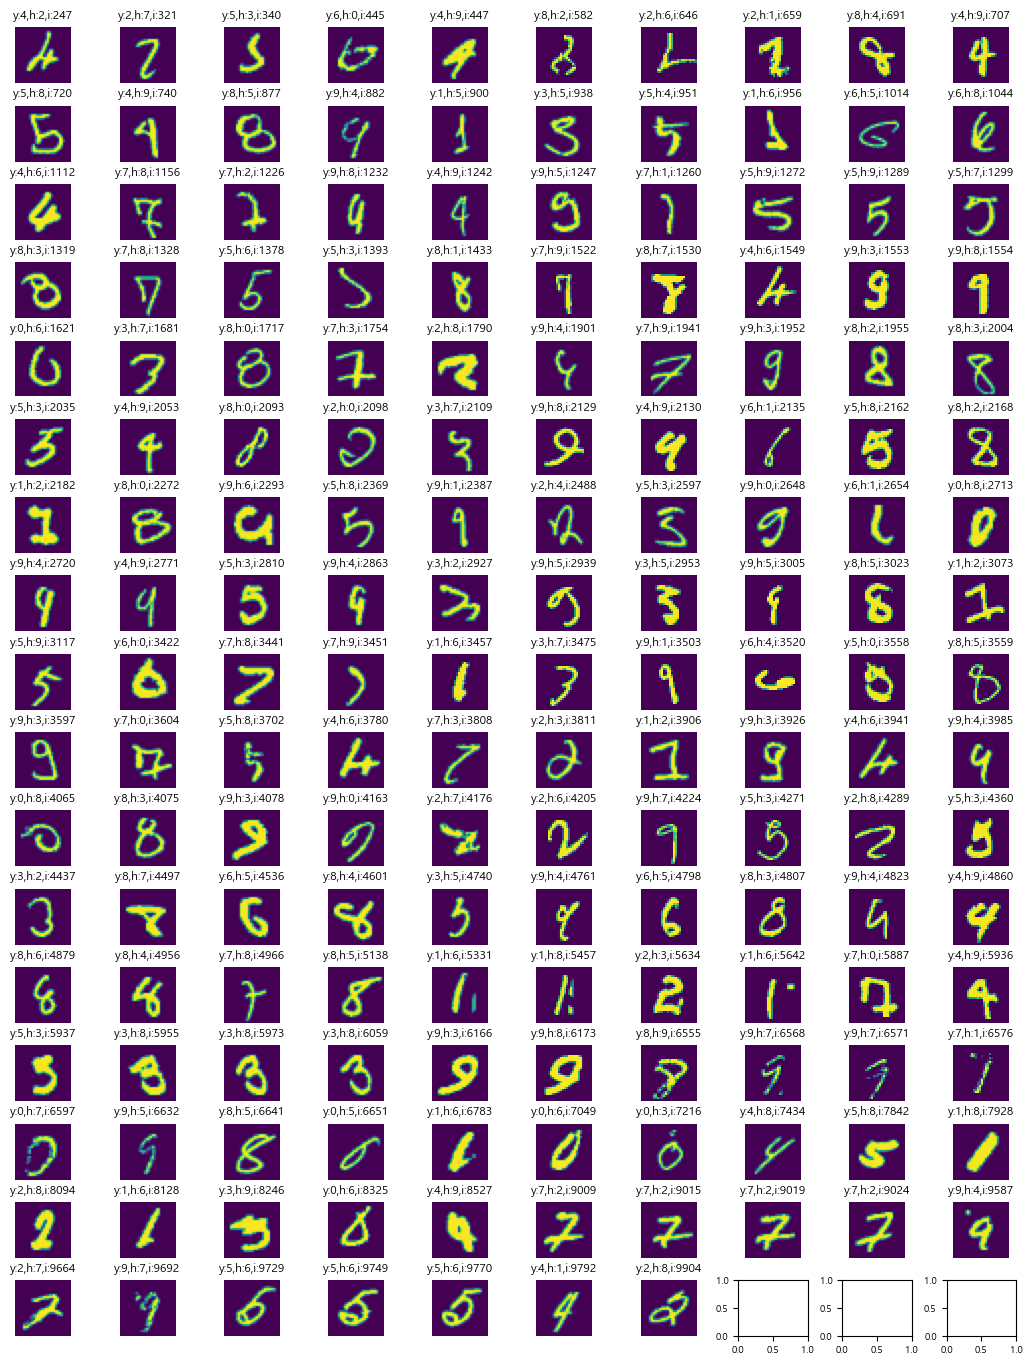

In [57]:
# DNN을 사용하여 예측이 틀린 데이터 출력(y_hat과 y_test가 다른 것들 167개 출력)
plt_row = 17
plt_col = 10
# plt.figure(figsize=(plt_col,plt_row))
plt.rcParams['figure.figsize'] = [plt_col+3, plt_row] # 이게 figsize가 더 크게 잡히네..?
plt.rc('font', family = 'Malgun Gothic', size = 7) # 한글시각화용
# plt.rc('font', family = 'NanumBarumGothic') # 코랩 한글 시각화
fig, axes = plt.subplots(plt_row, plt_col)
plt.subplots_adjust(hspace=0.4, wspace=0.5)
i = 0 # y_hat과 y_test의 index => y_hat[i], y_test[i] 비교
cnt = 0 # 이미지 출력회수
while i < len(y_test) and cnt < plt_row*plt_col :
    if  y_test[i] != y_hat.argmax(axis=1)[i] :
        x = cnt//plt_col ; y = cnt%plt_col
        axes[x,y].imshow(X_test[i].reshape(width, height))
        axes[x,y].axis('off')
        title = 'y:{},h:{},i:{}'.format(y_test[i], y_hat.argmax(axis=1)[i], i)
        axes[x,y].set_title(title)
        cnt +=1 # 이미지 출력 번호 증가
    i +=1 # 인덱스 증가

# 2. CNN(컨볼루션 레이어 포함)
- 딥러닝 자료 31page

In [59]:
%%time
# 1. 데이터 생성 및 전처리
width,height = 28,28
(X_train, y_train), (X_test,y_test) = mnist.load_data()
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 독립변수 28,28 => 784 1차원 -> 실수형으로 변환 -> 스케일 조정
X_train = X_train.reshape(-1,width*height).astype(np.float32)/255.0
X_val = X_val.reshape(-1,width*height).astype(np.float32)/255.0
X_test = X_test.reshape(-1,width*height).astype(np.float32)/255.0
# 타겟변수 원핫인코딩
Y_train = to_categorical(y_train)
Y_val = to_categorical(y_val)
Y_test = to_categorical(y_test)

X_train.shape, Y_train.shape, X_val.shape, Y_val.shape,X_test.shape, Y_test.shape

CPU times: total: 516 ms
Wall time: 512 ms


((50000, 784),
 (50000, 10),
 (10000, 784),
 (10000, 10),
 (10000, 784),
 (10000, 10))

In [ ]:
# 2. 모델 생성